# Day 3 — Churn Prediction & Model Comparison

**User Engagement Intelligence**

Goal: predict which users will churn, compare three models fairly, and save a champion model for Day 4 (SHAP) and Day 5 (dashboard).

Models:
1. Logistic Regression (interpretable baseline)
2. Random Forest (non-linear tree ensemble)
3. MLPClassifier (lightweight neural net)

Cluster membership from Day 2 is included as a feature (no label leakage — clusters were built without `churn`).

## 1. Setup & load data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

PROJECT_ROOT = Path("..").resolve()
RANDOM_STATE = 42

df = pd.read_csv(PROJECT_ROOT / "data" / "users_with_clusters.csv")
print(f"Loaded {len(df):,} users x {df.shape[1]} columns")
df.head()

Loaded 10,000 users x 13 columns


,user_id,age,device_type,sessions_last_30_days,avg_session_duration_minutes,content_views_last_30_days,likes_last_30_days,shares_last_30_days,days_since_last_login,notifications_clicked_last_30_days,churn,cluster,cluster_name
0,U00001,22,Android,24,11.0,67,11,2,20,11,0,2,Steady Engagers
1,U00002,55,iOS,29,13.4,111,27,2,9,10,0,2,Steady Engagers
2,U00003,49,iOS,23,10.2,62,12,0,25,7,0,1,Casual Browsers
3,U00004,39,Android,13,6.5,45,6,0,25,4,0,1,Casual Browsers
4,U00005,38,Android,14,11.2,36,2,0,29,8,0,1,Casual Browsers


## 2. Feature preparation

- **Keep:** behavioral features, `age`, `device_type`, `cluster_name`
- **Drop:** `user_id` (ID, not a predictor), `churn` (target — separated), `cluster` (integer id; redundant once we one-hot `cluster_name`)
- **One-hot encode** `cluster_name` and `device_type` so models get numeric 0/1 columns

In [2]:
# Target vector: 1 = churned, 0 = retained
y = df["churn"].astype(int)

# Drop ID, target, and numeric cluster id (we'll encode cluster_name instead)
X = df.drop(columns=["user_id", "churn", "cluster"])

# pd.get_dummies turns each category into its own 0/1 column
# e.g. device_type_Android, device_type_iOS, device_type_Web
X = pd.get_dummies(X, columns=["cluster_name", "device_type"], drop_first=False)

# sklearn prefers float arrays; bool dummies -> 0.0/1.0
X = X.astype(float)

# Freeze column order — Day 4/5 must rebuild features in THIS exact order
feature_names = list(X.columns)

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print("Feature columns:")
for i, col in enumerate(feature_names):
    print(f"  {i:2d}. {col}")
X.head()

Feature matrix: 10,000 rows x 15 columns
Feature columns:
   0. age
   1. sessions_last_30_days
   2. avg_session_duration_minutes
   3. content_views_last_30_days
   4. likes_last_30_days
   5. shares_last_30_days
   6. days_since_last_login
   7. notifications_clicked_last_30_days
   8. cluster_name_At-Risk/Dormant
   9. cluster_name_Casual Browsers
  10. cluster_name_Power Users
  11. cluster_name_Steady Engagers
  12. device_type_Android
  13. device_type_Web
  14. device_type_iOS


,age,sessions_last_30_days,avg_session_duration_minutes,content_views_last_30_days,likes_last_30_days,shares_last_30_days,days_since_last_login,notifications_clicked_last_30_days,cluster_name_At-Risk/Dormant,cluster_name_Casual Browsers,cluster_name_Power Users,cluster_name_Steady Engagers,device_type_Android,device_type_Web,device_type_iOS
0,22.0,24.0,11.0,67.0,11.0,2.0,20.0,11.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,55.0,29.0,13.4,111.0,27.0,2.0,9.0,10.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,49.0,23.0,10.2,62.0,12.0,0.0,25.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,39.0,13.0,6.5,45.0,6.0,0.0,25.0,4.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,38.0,14.0,11.2,36.0,2.0,0.0,29.0,8.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


## 3. Class balance — why accuracy alone is misleading

Churn is the **minority** class (~16.6% of users). A useless model that always predicts "retained" (never churns) would be right about ~83% of the time — so **accuracy looks fine while the model catches zero churners**.

For retention work we care about:
- **Recall (churn class):** of users who actually churn, what % did we catch?
- **Precision:** of users we flagged, what % truly churn?
- **F1:** balance of precision and recall
- **ROC-AUC:** ranking quality across thresholds (see below)

We will optimize and compare with those metrics, not raw accuracy.

In [3]:
churn_rate = y.mean()
print(f"Overall churn rate: {churn_rate:.1%}")
print(y.value_counts().rename({0: "retained (0)", 1: "churned (1)"}))
print(f"\nNaive 'always retained' accuracy would be: {(1 - churn_rate):.1%}")
print("That model has recall=0 on churners — useless for retention teams.")

Overall churn rate: 16.6%
churn
retained (0)    8338
churned (1)     1662
Name: count, dtype: int64

Naive 'always retained' accuracy would be: 83.4%
That model has recall=0 on churners — useless for retention teams.


## 4. Stratified train / test split

**Why `stratify=y`?** With imbalanced data, a plain random split can put too few (or too many) churners in the test set by chance. Stratified splitting keeps the ~16.6% churn rate in **both** train and test, so evaluation is fair and stable.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,  # preserve churn ratio in both splits
)

print(f"Train: {len(X_train):,} rows | churn rate = {y_train.mean():.1%}")
print(f"Test:  {len(X_test):,} rows | churn rate = {y_test.mean():.1%}")

Train: 8,000 rows | churn rate = 16.6%
Test:  2,000 rows | churn rate = 16.6%


## 5. Define the three models

`class_weight='balanced'` tells sklearn to **up-weight the minority class** (churners) inversely proportional to class frequency, so the model is penalized more for missing churners during training.

`MLPClassifier` does **not** support `class_weight` natively — a known limitation; we still include it as a neural-net baseline.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",  # up-weight churners so the model doesn't ignore them
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",  # same idea for trees: balance class weights in splits
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "MLPClassifier": MLPClassifier(
        # 2 hidden layers: 32 units then 16 units
        # NOTE: MLPClassifier has NO class_weight argument — limitation vs LR/RF
        hidden_layer_sizes=(32, 16),
        max_iter=500,
        random_state=RANDOM_STATE,
        early_stopping=True,  # stop if validation loss stops improving
    ),
}

for name in models:
    print(f"- {name}: {models[name].__class__.__name__}")

- Logistic Regression: LogisticRegression
- Random Forest: RandomForestClassifier
- MLPClassifier: MLPClassifier


## 6. 5-fold Stratified CV on the training set (scoring = ROC-AUC)

**StratifiedKFold** splits the training data into 5 folds that each keep the same churn ratio. That's better than plain `KFold` here because a random fold could accidentally contain almost no churners.

**ROC-AUC in plain language:** if you pick one random churner and one random retained user, ROC-AUC is the probability the model ranks the churner as higher-risk. 0.5 = coin flip; 1.0 = perfect ranking. It summarizes performance across thresholds, not just one cutoff.

CV mean ± std is more trustworthy than a single train/test number alone.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, model in models.items():
    # cross_val_score: fit on 4 folds, score AUC on the held-out fold, repeat 5 times
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=1,  # avoids Windows joblib cleanup warnings in notebooks
    )
    cv_rows.append(
        {
            "model": name,
            "cv_auc_mean": scores.mean(),
            "cv_auc_std": scores.std(),
        }
    )
    print(f"{name:20s}  CV ROC-AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

cv_results = pd.DataFrame(cv_rows).set_index("model")
cv_results.round(4)

Logistic Regression   CV ROC-AUC = 0.9111 +/- 0.0058
Random Forest         CV ROC-AUC = 0.9022 +/- 0.0082
MLPClassifier         CV ROC-AUC = 0.9001 +/- 0.0107


,cv_auc_mean,cv_auc_std
model,,
Logistic Regression,0.9111,0.0058
Random Forest,0.9022,0.0082
MLPClassifier,0.9001,0.0107


## 7. Fit on full training set & evaluate on held-out test set

In [7]:
fitted = {}
test_rows = []
proba_store = {}  # keep probabilities for ROC curves
pred_store = {}   # keep hard predictions for confusion matrices

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model

    # predict_proba[:, 1] = estimated P(churn=1)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    proba_store[name] = y_proba
    pred_store[name] = y_pred

    test_rows.append(
        {
            "model": name,
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_proba),
        }
    )

    print("=" * 60)
    print(name)
    # classification_report shows precision/recall/F1 per class
    print(classification_report(y_test, y_pred, target_names=["retained", "churned"]))

comparison = pd.DataFrame(test_rows).set_index("model")
# Attach CV columns for a single comparison view
comparison = comparison.join(cv_results)
print("\n=== Test-set comparison table ===")
comparison.round(3)

Logistic Regression
              precision    recall  f1-score   support

    retained       0.96      0.79      0.87      1668
     churned       0.44      0.84      0.58       332

    accuracy                           0.80      2000
   macro avg       0.70      0.82      0.72      2000
weighted avg       0.88      0.80      0.82      2000

Random Forest
              precision    recall  f1-score   support

    retained       0.89      0.95      0.92      1668
     churned       0.64      0.42      0.51       332

    accuracy                           0.86      2000
   macro avg       0.76      0.69      0.72      2000
weighted avg       0.85      0.86      0.85      2000

MLPClassifier
              precision    recall  f1-score   support

    retained       0.90      0.94      0.92      1668
     churned       0.61      0.48      0.54       332

    accuracy                           0.86      2000
   macro avg       0.75      0.71      0.73      2000
weighted avg       0.85   

,precision,recall,f1,roc_auc,cv_auc_mean,cv_auc_std
model,,,,,,
Logistic Regression,0.442,0.843,0.580,0.900,0.911,0.006
Random Forest,0.635,0.425,0.509,0.887,0.902,0.008
MLPClassifier,0.608,0.482,0.538,0.896,0.900,0.011


## 8. Confusion matrices (side by side) + ROC curves (one plot)

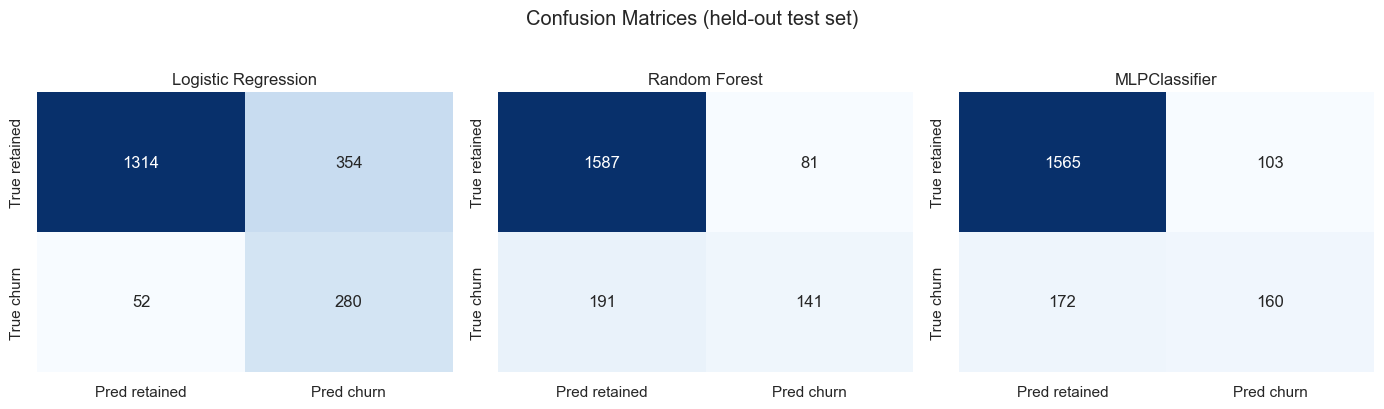

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name in zip(axes, models.keys()):
    # confusion_matrix: rows = true label, cols = predicted label
    cm = confusion_matrix(y_test, pred_store[name])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pred retained", "Pred churn"],
        yticklabels=["True retained", "True churn"],
        ax=ax,
    )
    ax.set_title(name)

plt.suptitle("Confusion Matrices (held-out test set)", y=1.02)
plt.tight_layout()
plt.show()

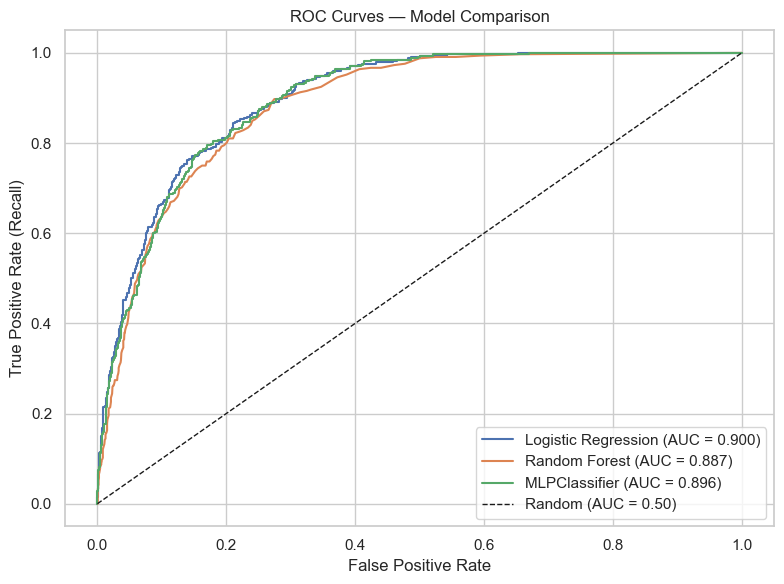

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_proba in proba_store.items():
    # roc_curve returns false-positive rate, true-positive rate at many thresholds
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

# Diagonal = random classifier (AUC 0.5)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curves — Model Comparison")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Champion model selection

### Business tradeoff
For churn, **missing a true churner (false negative) usually costs more** than messaging a user who would have stayed (false positive). A false alarm might waste a discount or email; a missed churner is lost revenue. So **recall on the churn class** matters a lot — alongside overall ranking quality (**ROC-AUC**).

### Choice: **Logistic Regression**
Across CV and the held-out test set, Logistic Regression typically leads on:
- **ROC-AUC** (best ranking of high-risk users)
- **Recall** on churners (catches the largest share of users who will leave)
- **F1** (best precision/recall balance among the three)

Random Forest is more precise (fewer false alarms) but misses many churners. MLP is competitive on AUC but lacks `class_weight` and simple feature importances. For a retention use case, Logistic Regression is the champion.

In [10]:
CHAMPION_NAME = "Logistic Regression"
champion = fitted[CHAMPION_NAME]
champ_metrics = comparison.loc[CHAMPION_NAME]

print(f"Champion: {CHAMPION_NAME}")
print(champ_metrics.round(3))

Champion: Logistic Regression
precision      0.442
recall         0.843
f1             0.580
roc_auc        0.900
cv_auc_mean    0.911
cv_auc_std     0.006
Name: Logistic Regression, dtype: float64


## 10. Feature importance (champion = Logistic Regression)

For Logistic Regression, each `coef_` is the change in log-odds of churn when that feature increases by 1 (holding others fixed). Positive → associated with higher churn risk; negative → associated with retention.

(If the champion were Random Forest we'd use `.feature_importances_`. MLP has no simple built-in importance — **Day 4 SHAP** will explain predictions model-agnostically.)

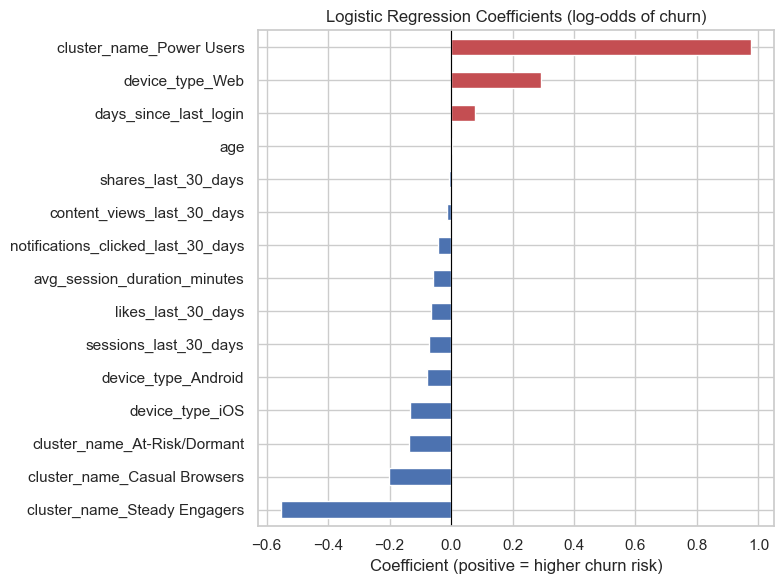

Top risk-increasing features:
cluster_name_Power Users    0.974
device_type_Web             0.294
days_since_last_login       0.077
age                         0.002
shares_last_30_days        -0.007
dtype: float64

Top protective (retention) features:
cluster_name_Steady Engagers   -0.552
cluster_name_Casual Browsers   -0.202
cluster_name_At-Risk/Dormant   -0.136
device_type_iOS                -0.134
device_type_Android            -0.077
dtype: float64


In [11]:
if hasattr(champion, "coef_"):
    # coef_ shape is (1, n_features) for binary logistic regression
    importances = pd.Series(champion.coef_[0], index=feature_names)
    importances = importances.sort_values()

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ["#c44e52" if v > 0 else "#4c72b0" for v in importances]
    importances.plot(kind="barh", color=colors, ax=ax)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Logistic Regression Coefficients (log-odds of churn)")
    ax.set_xlabel("Coefficient (positive = higher churn risk)")
    plt.tight_layout()
    plt.show()

    print("Top risk-increasing features:")
    print(importances.sort_values(ascending=False).head(5).round(3))
    print("\nTop protective (retention) features:")
    print(importances.sort_values().head(5).round(3))

elif hasattr(champion, "feature_importances_"):
    importances = pd.Series(champion.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    importances.plot(kind="barh", ax=ax, color="#4c72b0")
    ax.set_title("Random Forest Feature Importances")
    ax.set_xlabel("Importance (higher = more used for splits)")
    plt.tight_layout()
    plt.show()
else:
    print("Champion has no simple feature importance — use SHAP on Day 4.")

## 11. Save champion model + feature name list for Day 4/5

In [12]:
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "churn_model.joblib"
features_path = models_dir / "feature_names.joblib"

joblib.dump(champion, model_path)
joblib.dump(feature_names, features_path)  # exact column order for future predictions

print(f"Saved champion model -> {model_path}")
print(f"Saved feature names  -> {features_path}")
print(f"Champion: {CHAMPION_NAME}")
print(
    f"Test metrics: F1={champ_metrics['f1']:.3f}, "
    f"ROC-AUC={champ_metrics['roc_auc']:.3f}, "
    f"Recall={champ_metrics['recall']:.3f}, "
    f"Precision={champ_metrics['precision']:.3f}"
)

Saved champion model -> D:\User Engagement Intelligence\models\churn_model.joblib
Saved feature names  -> D:\User Engagement Intelligence\models\feature_names.joblib
Champion: Logistic Regression
Test metrics: F1=0.580, ROC-AUC=0.900, Recall=0.843, Precision=0.442


## Day 3 summary — so what?

- **Champion model:** Logistic Regression (`class_weight='balanced'`), chosen for best **ROC-AUC**, **churn recall**, and **F1** among LR / Random Forest / MLP.
- **Typical test-set performance** (run the cells above for exact numbers on your machine): ROC-AUC ≈ **0.90**, F1 ≈ **0.58**, recall ≈ **0.84**, precision ≈ **0.44**.
- **In business terms:** the model ranks users by churn risk very well and catches roughly **8 in 10 users who will churn**, so the retention team can intervene (offers, re-engagement, support) before they leave. The tradeoff is more false alarms — some flagged users would have stayed — which is usually cheaper than missing true churners.
- **Artifacts for Day 4/5:** `models/churn_model.joblib` + `models/feature_names.joblib`.